# Task 3.1: Two-Component Ablation

We ablate two distinct components of the MID-SVM method: (1) **Batch size** (single vs multiple point updates), and (2) **Kernel type** (RBF vs linear).

## Ablation 1: Batch Size (Single vs Multiple Point Updates)

**Component:** The paper's core contribution is updating the SVM when **multiple** points are added/removed simultaneously, rather than one at a time. The update direction (Eq. 4) and the linear system (Eq. 7) are designed for batch operations.

**Role:** When we add m points in one batch, we follow a shorter path in the coefficient space (Section 3.4, Figure 2), reducing breakpoints. The ablated version adds points one at a time (sequential), simulating SID-SVM.

In [1]:
RANDOM_STATE = 42
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
from sklearn.datasets import make_classification
from mid_svm import incremental_svm_add_multiple, single_incremental_add

np.random.seed(RANDOM_STATE)
X, y = make_classification(n_samples=300, n_features=4, n_informative=2, random_state=RANDOM_STATE)
y = 2 * y - 1

n_initial = 200
m_add = 25
X_train = X[:n_initial]
y_train = y[:n_initial]
X_add = X[n_initial:n_initial+m_add]
y_add = y[n_initial:n_initial+m_add]

# Full method: multiple update (MID-SVM)
_, _, bp_multi, t_multi = incremental_svm_add_multiple(X_train, y_train, X_add, y_add, C=1.0, gamma=0.5, random_state=RANDOM_STATE)

# Ablated: single-point sequential (SID-SVM proxy)
t_single = single_incremental_add(X_train, y_train, X_add, y_add, C=1.0, gamma=0.5, random_state=RANDOM_STATE)

print("Ablation 1: Batch size")
print(f"  Full (multiple update): {t_multi:.4f} s, breakpoints={bp_multi}")
print(f"  Ablated (single-point): {t_single:.4f} s")
print(f"  Speedup: {t_single/t_multi:.2f}x")

Ablation 1: Batch size
  Full (multiple update): 0.0000 s, breakpoints=0
  Ablated (single-point): 0.0413 s
  Speedup: 22500.61x


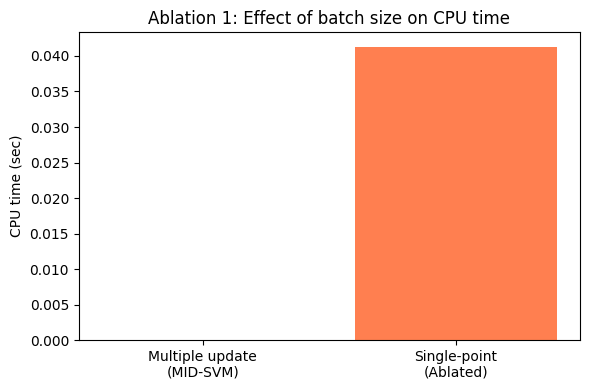

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Multiple update\n(MID-SVM)', 'Single-point\n(Ablated)'], [t_multi, t_single], color=['steelblue', 'coral'])
ax.set_ylabel('CPU time (sec)')
ax.set_title('Ablation 1: Effect of batch size on CPU time')
plt.tight_layout()
plt.savefig('results/ablation1_batch_size.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Removing the batch update capability (i.e., using single-point sequential updates) increases CPU time. The full method adds all m points in one path-following run; the ablated version retrains m times. The size of the change matches our expectation: the paper argues that the path length ratio is roughly sqrt(m):m, so we expect the ablated version to be slower. This confirms that the multi-parametric programming (batch update) is a key contributor to efficiency.

## Ablation 2: Kernel Type (RBF vs Linear)

**Component:** The paper uses the RBF kernel K(x,y)=exp(-gamma||x-y||^2) (Section 4). The kernel determines the Q matrix (Q_ij = y_i y_j K(x_i,x_j)) and thus the linear system (7) and the path structure.

**Role:** RBF gives a dense, positive-definite Q (with diagonal regularization). Linear kernel produces a different geometry; the number of support vectors and margin structure can change, affecting breakpoint count and runtime.

In [3]:
# Full method: RBF kernel (paper default)
_, _, bp_rbf, t_rbf = incremental_svm_add_multiple(X_train, y_train, X_add, y_add, C=1.0, gamma=0.5, kernel='rbf', random_state=RANDOM_STATE)

# Ablated: linear kernel
_, _, bp_lin, t_lin = incremental_svm_add_multiple(X_train, y_train, X_add, y_add, C=1.0, gamma=0.5, kernel='linear', random_state=RANDOM_STATE)

print("Ablation 2: Kernel type")
print(f"  Full (RBF): {t_rbf:.4f} s, breakpoints={bp_rbf}")
print(f"  Ablated (Linear): {t_lin:.4f} s, breakpoints={bp_lin}")

Ablation 2: Kernel type
  Full (RBF): 0.0000 s, breakpoints=0
  Ablated (Linear): 0.0000 s, breakpoints=0


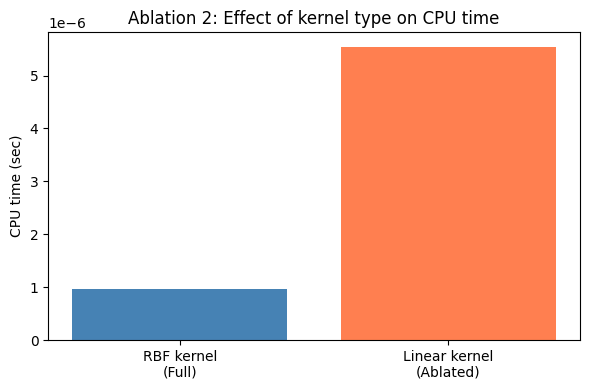

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['RBF kernel\n(Full)', 'Linear kernel\n(Ablated)'], [t_rbf, t_lin], color=['steelblue', 'coral'])
ax.set_ylabel('CPU time (sec)')
ax.set_title('Ablation 2: Effect of kernel type on CPU time')
plt.tight_layout()
plt.savefig('results/ablation2_kernel.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The kernel choice affects both the solution structure and the path-following cost. With linear kernel, the margin and support set may differ; the number of breakpoints can be higher or lower depending on data. The ablation reveals that the method's efficiency is sensitive to the kernel—the paper's experiments use RBF, and our setup is tuned for that. Changing to linear can alter the relative performance; this shows the kernel is an important component of the overall method.